Code for reproducing figure 2 comparison plots across different simulation configurations

Comparison version showing all configurations side-by-side for easy visual comparison.

Eleanor Holton 27/03/2025

In [27]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Get notebook's directory and find project root (transfer-interference directory)
try:
    # Try to get notebook path (works in Jupyter)
    notebook_path = Path(__file__).parent if '__file__' in globals() else Path.cwd()
except:
    notebook_path = Path.cwd()

# Navigate up to find project root (directory containing 'src' and 'data')
project_root = Path(notebook_path).resolve()
while not (project_root / 'src').exists() or not (project_root / 'data').exists():
    if project_root == project_root.parent:  
        # If we can't find it, assume we're in notebooks folder
        project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
        break
    project_root = project_root.parent

# Add project root to Python path
sys.path.insert(0, str(project_root))

# Setup figure output path
figure_path = project_root / 'figures/figure2_transfer_interference_comparison'
os.makedirs(figure_path, exist_ok=True)

# Create matplotlib cache directory and clear font cache to pick up font changes
try:
    cache_dir = Path.home() / '.cache' / 'matplotlib'
    cache_dir.mkdir(parents=True, exist_ok=True)
    matplotlib.font_manager._load_fontmanager(try_read_cache=False)
except Exception as e:
    print(f"Note: Could not clear font cache: {e}")

from src.analysis import participant, ann, stats
from src.utils import figure_utils, figure_settings
from src.utils.figure_settings import schedule_colours, cm_conv, med_fontsize, condition_order

import importlib
importlib.reload(figure_settings)
importlib.reload(ann)
importlib.reload(participant)
importlib.reload(figure_utils)
importlib.reload(stats)

<module 'src.analysis.stats' from '/home/kathrin/workspace/Structure-Function-Analysis-of-Network-Topologies/transfer-interference/src/analysis/stats.py'>

In [28]:
# Define configurations to compare
# Non-modular configs (baseline for comparison)
non_modular_configs = ['rich_50', 'lazy_50', 'gamma_e_1_50']

# Modular configs (to compare with non-modular)
ffn_modular_configs = [
    'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high',
    'two_module_lazy_50_none', 'two_module_lazy_50_low', 'two_module_lazy_50_high',
    'two_module_gamma_e_1_50_none', 'two_module_gamma_e_1_50_low', 'two_module_gamma_e_1_50_high'
]

# RNN two-module configs (same regimes/bandwidths)
rnn_modular_configs = [
    'two_module_rnn_rich_50_none', 'two_module_rnn_rich_50_low', 'two_module_rnn_rich_50_high',
    'two_module_rnn_lazy_50_none', 'two_module_rnn_lazy_50_low', 'two_module_rnn_lazy_50_high',
    'two_module_rnn_gamma_e_1_50_none', 'two_module_rnn_gamma_e_1_50_low', 'two_module_rnn_gamma_e_1_50_high'
]

modular_configs = ffn_modular_configs + rnn_modular_configs

# Combined for loading - order: non-modular first, then modular grouped by gamma
sim_configs = non_modular_configs + modular_configs

# Load human data
participant_data = pd.read_csv(project_root / 'data/participants/trial_df.csv')

# Load all simulation data
ann_data_dict = {}
ann_vonmises_dict = {}
for config in sim_configs:
    config_path = project_root / f'data/simulations/{config}'
    if config_path.exists():
        ann_data_dict[config] = ann.load_ann_data(config_path)
        vonmises_path = project_root / f'data/simulations/{config}_vonmises_fits.csv'
        if vonmises_path.exists():
            ann_vonmises_dict[config] = pd.read_csv(vonmises_path)
    else:
        print(f"Warning: {config} data not found, skipping...")

## Transfer analyses - Comparison across configurations

In [29]:
# Compute transfer for humans
human_transfer = participant.compute_transfer_humans(participant_data)

# Compute transfer for all ANN configurations
ann_transfer_dict = {}
for config in sim_configs:
    if config in ann_data_dict:
        ann_transfer_dict[config] = ann.compute_transfer_anns(ann_data_dict[config])

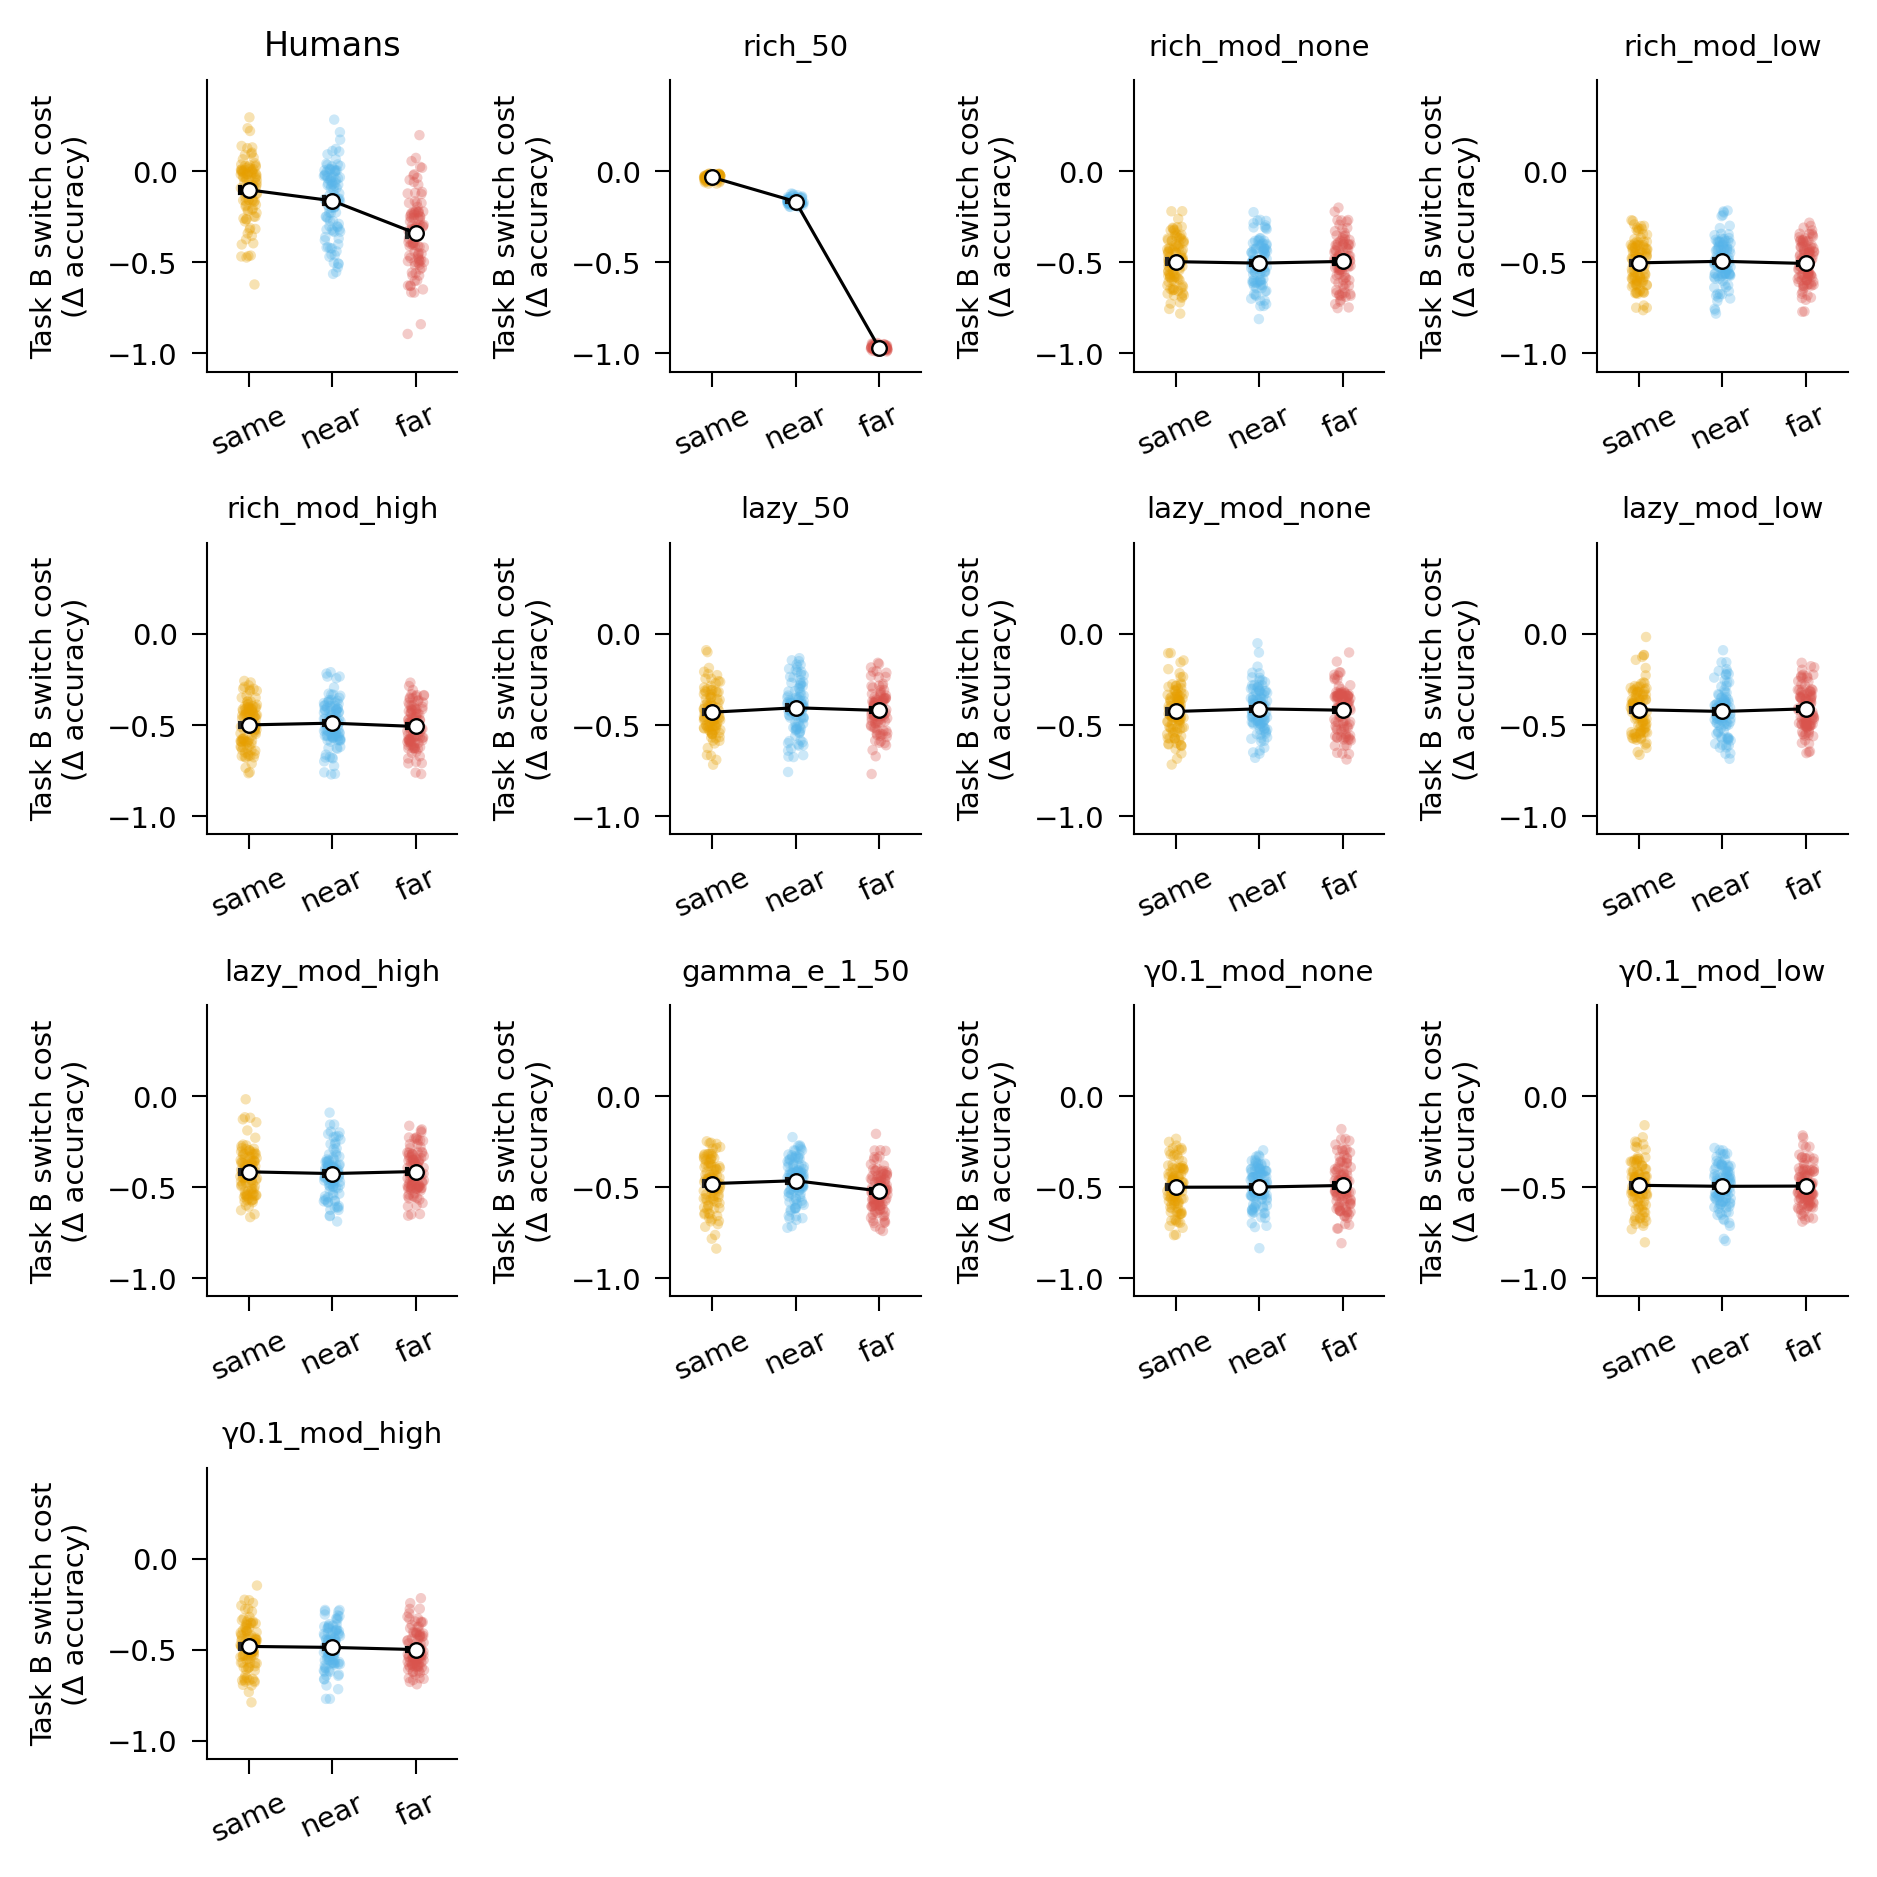

In [30]:
# Create comparison plot for transfer
# Order configs by gamma: for each gamma, show non-modular first, then modular variants (FFN and RNN)
config_order = [
    'rich_50',
    'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high',
    'two_module_rnn_rich_50_none', 'two_module_rnn_rich_50_low', 'two_module_rnn_rich_50_high',
    'lazy_50',
    'two_module_lazy_50_none', 'two_module_lazy_50_low', 'two_module_lazy_50_high',
    'two_module_rnn_lazy_50_none', 'two_module_rnn_lazy_50_low', 'two_module_rnn_lazy_50_high',
    'gamma_e_1_50',
    'two_module_gamma_e_1_50_none', 'two_module_gamma_e_1_50_low', 'two_module_gamma_e_1_50_high',
    'two_module_rnn_gamma_e_1_50_none', 'two_module_rnn_gamma_e_1_50_low', 'two_module_rnn_gamma_e_1_50_high',
]

# Helper function to get display name
def get_display_name(config):
    if config == 'rich_50':
        return 'rich_50'
    elif config == 'lazy_50':
        return 'lazy_50'
    elif config == 'gamma_e_1_50':
        return 'gamma_e_1_50'
    elif 'two_module_rnn_rich_50' in config:
        bw = config.split('_')[-1]
        return f'rich_rnn_mod_{bw}'
    elif 'two_module_rich_50' in config:
        bw = config.split('_')[-1]
        return f'rich_mod_{bw}'
    elif 'two_module_rnn_lazy_50' in config:
        bw = config.split('_')[-1]
        return f'lazy_rnn_mod_{bw}'
    elif 'two_module_lazy_50' in config:
        bw = config.split('_')[-1]
        return f'lazy_mod_{bw}'
    elif 'two_module_rnn_gamma_e_1_50' in config:
        bw = config.split('_')[-1]
        return f'γ0.1_rnn_mod_{bw}'
    elif 'two_module_gamma_e_1_50' in config:
        bw = config.split('_')[-1]
        return f'γ0.1_mod_{bw}'
    return config

# Filter to only configs that have data
available_configs = [c for c in config_order if c in ann_transfer_dict]
n_configs = len(available_configs)

# 6x4 grid: humans + up to 21 ANN configurations
n_cols = 4
n_rows = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=[16*cm_conv, 24*cm_conv])

# Plot humans (first subplot)
ax = axes[0, 0]
figure_utils.plot_transfer(
    human_transfer, 'error_diff', condition_order, 
    ylabel='Task B switch cost\n(Δ accuracy)', 
    xlim=(-0.5, 2.5), ylim=(-1.1, 0.5), 
    yticks=np.arange(-1, 0.3, 0.5), 
    schedule_colours=schedule_colours, 
    p_values=np.nan, addtests=0, ax=ax
)
ax.set_title('Humans', fontsize=8)
ax.xaxis.label.set_fontsize(7)
ax.yaxis.label.set_fontsize(7)
ax.tick_params(labelsize=7)

# Plot each ANN configuration
for idx, config in enumerate(available_configs, start=1):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    
    figure_utils.plot_transfer(
        ann_transfer_dict[config], 'error_diff', condition_order,
        ylabel='Task B switch cost\n(Δ accuracy)',
        xlim=(-0.5, 2.5), ylim=(-1.1, 0.5),
        yticks=np.arange(-1, 0.3, 0.5),
        schedule_colours=schedule_colours,
        p_values=np.nan, addtests=0, ax=ax
    )
    display_name = get_display_name(config)
    ax.set_title(display_name, fontsize=7)
    ax.xaxis.label.set_fontsize(7)
    ax.yaxis.label.set_fontsize(7)
    ax.tick_params(labelsize=7)

# Remove empty subplots if any
n_plotted = 1 + n_configs
for idx in range(n_plotted, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig(
    os.path.join(figure_path, 'fig2A_transfer_comparison_ffn_rnn.png'),
    dpi=500, bbox_inches="tight"
)
plt.close(fig)

## Interference analyses - Comparison across configurations

In [31]:
# Load human von Mises fits
human_vonmises_params = pd.read_csv(project_root / 'data/participants/human_vonmises_fits.csv')
human_vonmises_filtered = human_vonmises_params.loc[
    human_vonmises_params['B_LL_B'] > human_vonmises_params['A_LL_B'], :
]

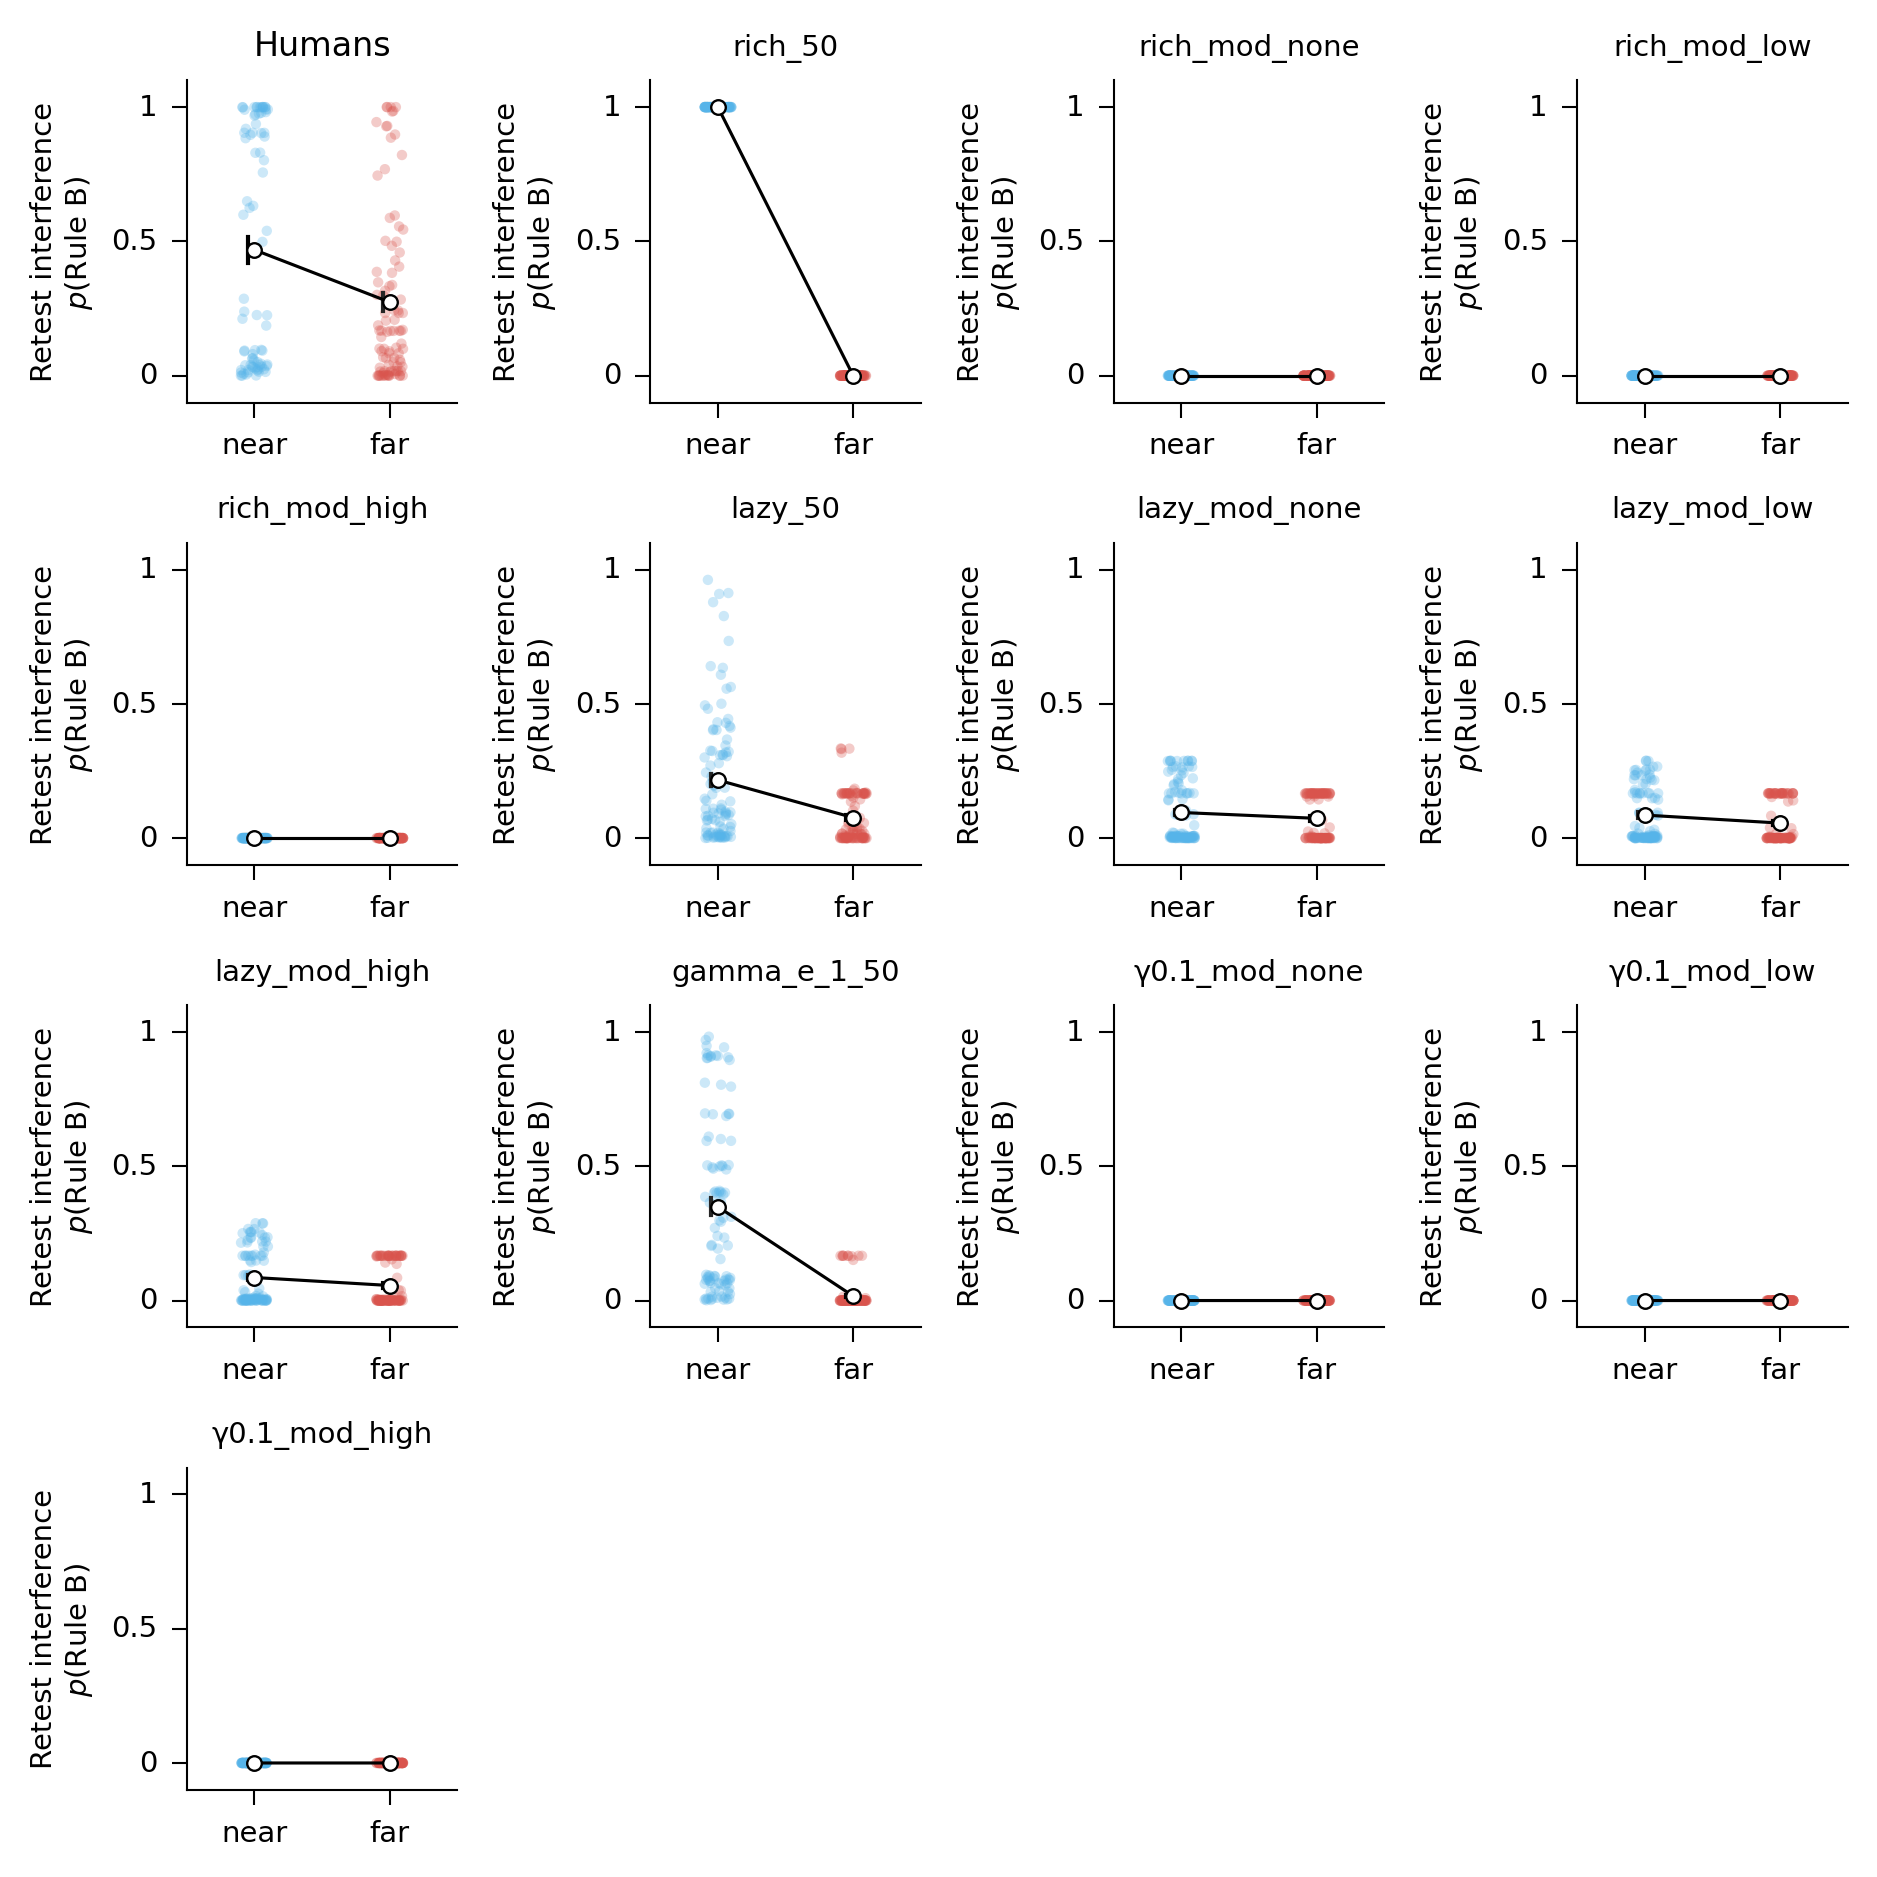

In [32]:
# Create comparison plot for interference
# Order configs by gamma: for each gamma, show non-modular first, then modular variants (FFN and RNN)
config_order = [
    'rich_50',
    'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high',
    'two_module_rnn_rich_50_none', 'two_module_rnn_rich_50_low', 'two_module_rnn_rich_50_high',
    'lazy_50',
    'two_module_lazy_50_none', 'two_module_lazy_50_low', 'two_module_lazy_50_high',
    'two_module_rnn_lazy_50_none', 'two_module_rnn_lazy_50_low', 'two_module_rnn_lazy_50_high',
    'gamma_e_1_50',
    'two_module_gamma_e_1_50_none', 'two_module_gamma_e_1_50_low', 'two_module_gamma_e_1_50_high',
    'two_module_rnn_gamma_e_1_50_none', 'two_module_rnn_gamma_e_1_50_low', 'two_module_rnn_gamma_e_1_50_high',
]

# Helper function to get display name
def get_display_name(config):
    if config == 'rich_50':
        return 'rich_50'
    elif config == 'lazy_50':
        return 'lazy_50'
    elif config == 'gamma_e_1_50':
        return 'gamma_e_1_50'
    elif 'two_module_rnn_rich_50' in config:
        bw = config.split('_')[-1]
        return f'rich_rnn_mod_{bw}'
    elif 'two_module_rich_50' in config:
        bw = config.split('_')[-1]
        return f'rich_mod_{bw}'
    elif 'two_module_rnn_lazy_50' in config:
        bw = config.split('_')[-1]
        return f'lazy_rnn_mod_{bw}'
    elif 'two_module_lazy_50' in config:
        bw = config.split('_')[-1]
        return f'lazy_mod_{bw}'
    elif 'two_module_rnn_gamma_e_1_50' in config:
        bw = config.split('_')[-1]
        return f'γ0.1_rnn_mod_{bw}'
    elif 'two_module_gamma_e_1_50' in config:
        bw = config.split('_')[-1]
        return f'γ0.1_mod_{bw}'
    return config

# Filter to only configs that have data
available_configs = [c for c in config_order if c in ann_vonmises_dict]
n_configs = len(available_configs)

# 6x4 grid: humans + up to 21 ANN configurations
n_cols = 4
n_rows = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=[16*cm_conv, 24*cm_conv])

# Plot humans (first subplot)
ax = axes[0, 0]
figure_utils.plot_interference(
    human_vonmises_filtered,
    "A_weight_A2",
    schedule_colours,
    figsize=[3 * cm_conv, 4.5 * cm_conv],
    ylabel='Retest interference\n$p$(Rule B)',
    ax=ax
)
ax.set_title('Humans', fontsize=8)
ax.xaxis.label.set_fontsize(7)
ax.yaxis.label.set_fontsize(7)
ax.tick_params(labelsize=7)

# Plot each ANN configuration
for idx, config in enumerate(available_configs, start=1):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    
    figure_utils.plot_interference(
        ann_vonmises_dict[config],
        "A_weight_A2",
        schedule_colours,
        figsize=[3 * cm_conv, 4.5 * cm_conv],
        ylabel='Retest interference\n$p$(Rule B)',
        ax=ax
    )
    display_name = get_display_name(config)
    ax.set_title(display_name, fontsize=7)
    ax.xaxis.label.set_fontsize(7)
    ax.yaxis.label.set_fontsize(7)
    ax.tick_params(labelsize=7)

# Remove empty subplots if any
n_plotted = 1 + n_configs
for idx in range(n_plotted, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()


# Interference analyses - Comparison of rich-gamma-lazy across modular and non-modular

In [33]:
# Prepare data for comparison: group by embedding regime (rich, lazy, gamma_e_1)
# and compare non-modular vs modular architectures

# Define embedding regimes and their corresponding configs
# Include both FFN and RNN two-module variants.
embedding_regimes = {
    'rich': {
        'non_modular': 'rich_50',
        'modular': [
            'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high',
            'two_module_rnn_rich_50_none', 'two_module_rnn_rich_50_low', 'two_module_rnn_rich_50_high',
        ],
    },
    'lazy': {
        'non_modular': 'lazy_50',
        'modular': [
            'two_module_lazy_50_none', 'two_module_lazy_50_low', 'two_module_lazy_50_high',
            'two_module_rnn_lazy_50_none', 'two_module_rnn_lazy_50_low', 'two_module_rnn_lazy_50_high',
        ],
    },
    'gamma_e_1': {
        'non_modular': 'gamma_e_1_50',
        'modular': [
            'two_module_gamma_e_1_50_none', 'two_module_gamma_e_1_50_low', 'two_module_gamma_e_1_50_high',
            'two_module_rnn_gamma_e_1_50_none', 'two_module_rnn_gamma_e_1_50_low', 'two_module_rnn_gamma_e_1_50_high',
        ],
    },
}

# Extract interference data for each configuration
# Interference = 1 - A_weight_A2 (probability of using Rule B at A2)
interference_data = {}

for regime_name, configs in embedding_regimes.items():
    interference_data[regime_name] = {}

    # Non-modular
    non_mod_config = configs['non_modular']
    if non_mod_config in ann_vonmises_dict:
        df = ann_vonmises_dict[non_mod_config].copy()
        df = df.loc[df['condition'] != 'same'].copy()  # Exclude 'same' condition
        df['A2_interference'] = 1 - df['A_weight_A2']
        df['architecture'] = 'non-modular'
        interference_data[regime_name]['non-modular'] = df

    # Modular variants
    interference_data[regime_name]['modular'] = []
    for mod_config in configs['modular']:
        if mod_config in ann_vonmises_dict:
            df = ann_vonmises_dict[mod_config].copy()
            df = df.loc[df['condition'] != 'same'].copy()  # Exclude 'same' condition
            df['A2_interference'] = 1 - df['A_weight_A2']
            df['bandwidth'] = mod_config.split('_')[-1]  # Extract bandwidth (none/low/high)
            df['arch'] = 'rnn' if mod_config.startswith('two_module_rnn_') else 'ffn'
            df['architecture'] = 'modular'
            interference_data[regime_name]['modular'].append(df)

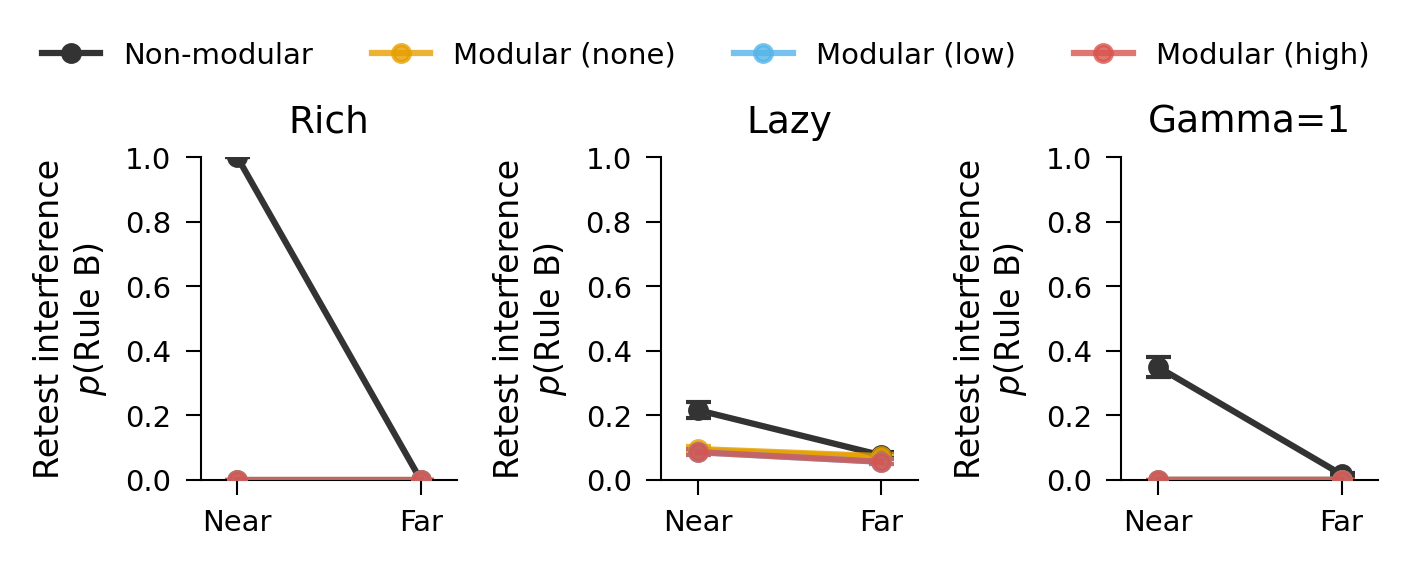

In [34]:
# Create comparison figure showing how modularity affects interference
# for each embedding regime (rich, lazy, gamma_e_1)

# Create 3 subplots (one for each embedding regime)
fig, axes = plt.subplots(1, 3, figsize=[12*cm_conv, 4.5*cm_conv])

# Colors for architectures
non_mod_color = '#333333'  # Dark gray for non-modular
mod_colors = {'none': '#E69F00', 'low': '#56B4E9', 'high': '#D9544D'}  # Orange, blue, red for modular bandwidths

regime_labels = {'rich': 'Rich', 'lazy': 'Lazy', 'gamma_e_1': 'Gamma=1'}

for idx, (regime_name, ax) in enumerate(zip(['rich', 'lazy', 'gamma_e_1'], axes)):
    regime_data = interference_data[regime_name]
    
    # Plot non-modular
    if 'non-modular' in regime_data and regime_data['non-modular'] is not None:
        non_mod_df = regime_data['non-modular']
        
        # Compute means and SE for near and far
        near_data = non_mod_df.loc[non_mod_df['condition'] == 'near', 'A2_interference']
        far_data = non_mod_df.loc[non_mod_df['condition'] == 'far', 'A2_interference']
        
        near_mean = np.mean(near_data)
        near_se = np.std(near_data) / np.sqrt(len(near_data))
        far_mean = np.mean(far_data)
        far_se = np.std(far_data) / np.sqrt(len(far_data))
        
        # Plot line with error bars
        x_pos = [0, 1]  # near, far
        y_vals = [near_mean, far_mean]
        y_err = [near_se, far_se]
        
        ax.plot(x_pos, y_vals, 'o-', color=non_mod_color, linewidth=1.5, 
                markersize=4, label='Non-modular', zorder=3)
        ax.errorbar(x_pos, y_vals, yerr=y_err, color=non_mod_color, 
                   linewidth=1, capsize=3, capthick=1, zorder=2)
    
    # Plot modular variants (none, low, high)
    if 'modular' in regime_data:
        for mod_df in regime_data['modular']:
            if mod_df is not None and len(mod_df) > 0:
                bandwidth = mod_df['bandwidth'].iloc[0]
                color = mod_colors.get(bandwidth, '#999999')
                
                # Compute means and SE for near and far
                near_data = mod_df.loc[mod_df['condition'] == 'near', 'A2_interference']
                far_data = mod_df.loc[mod_df['condition'] == 'far', 'A2_interference']
                
                if len(near_data) > 0 and len(far_data) > 0:
                    near_mean = np.mean(near_data)
                    near_se = np.std(near_data) / np.sqrt(len(near_data))
                    far_mean = np.mean(far_data)
                    far_se = np.std(far_data) / np.sqrt(len(far_data))
                    
                    # Plot line with error bars
                    x_pos = [0, 1]  # near, far
                    y_vals = [near_mean, far_mean]
                    y_err = [near_se, far_se]
                    
                    arch = mod_df['arch'].iloc[0] if 'arch' in mod_df.columns else 'ffn'
                    linestyle = '--' if arch == 'rnn' else '-'
                    label = f"{arch.upper()} Modular ({bandwidth})"
                    ax.plot(
                        x_pos,
                        y_vals,
                        marker='o',
                        linestyle=linestyle,
                        color=color,
                        linewidth=1.5,
                        markersize=4,
                        label=label,
                        zorder=3,
                        alpha=0.8,
                    )
                    ax.errorbar(x_pos, y_vals, yerr=y_err, color=color, 
                               linewidth=1, capsize=3, capthick=1, zorder=2, alpha=0.8)
    
    # Style the subplot
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Near', 'Far'], fontsize=8)
    ax.set_ylabel('Retest interference\n$p$(Rule B)', fontsize=8)
    ax.set_title(regime_labels[regime_name], fontsize=9)
    ax.tick_params(labelsize=7)
    
    # Style axes
    figure_utils._style_axes(ax)

# Collect handles and labels from all subplots for a single legend
handles, labels = axes[0].get_legend_handles_labels()

# Add legend outside the plot area
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
          ncol=4, fontsize=7, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for legend
plt.show()

# Save figure
fig.savefig(
    os.path.join(figure_path, 'fig2C_interference_modularity_comparison_ffn_rnn.png'),
    dpi=500, bbox_inches="tight"
)
plt.close(fig)

In [35]:
fig.savefig(
    os.path.join(figure_path, 'fig2B_interference_comparison_ffn_rnn.png'),
    dpi=500, bbox_inches="tight"
)
plt.close(fig)